In [1]:
import numpy as np
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import cv2 as cv
from sklearn.preprocessing import StandardScaler
from rich.progress import track
import os
import numpy as np
from cachetools import cached

In [2]:
CATEGORIES = ("Lotus", "Tulip", "Orchid", "Lilly", "Sunflower")
DATASET_PATH = "./data/flowers"
IMG_SIZE = 128

Output()

(800, 16384)


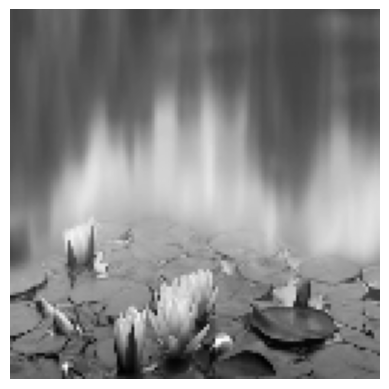

In [3]:
@cached({})
def load_dataset(path: str):
    files = os.listdir(path)
    data = []
    for file in track(files, description=f"Loading dataset from {path}"):
        img = cv.imread(os.path.join(path, file))
        assert img is not None, "Image not found"
        img = cv.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = img.flatten()
        data.append(img)
    return np.array(data)


lilly_df = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[0]))
print(lilly_df.shape)
plt.imshow(lilly_df[0].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
plt.axis("off")
plt.show()

In [4]:
X_train = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[0]))
Y_train = 0 * np.ones(len(X_train)) 
for i in range(1, len(CATEGORIES)):
    category_data = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[i]))
    X_train = np.vstack(
        [X_train] + [category_data]
    )
    Y_train = np.hstack(
        [Y_train] + [i * np.ones(len(category_data))]
    )

X_test = load_dataset(os.path.join(DATASET_PATH, "val", CATEGORIES[0]))
Y_test = 0 * np.ones(len(X_test)) 
for i in range(1, len(CATEGORIES)):
    category_data = load_dataset(os.path.join(DATASET_PATH, "val", CATEGORIES[i]))
    X_test = np.vstack(
        [X_test] + [category_data]
    )
    Y_test = np.hstack(
        [Y_test] + [i * np.ones(len(category_data))]
    )

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [5]:
class AbstractClassifier(ABC):
    @abstractmethod
    def fit(self, X: np.ndarray, y: np.ndarray):
        pass

    @abstractmethod
    def predict(self, X: np.ndarray) -> np.ndarray:
        pass


In [6]:
class OneLayerNN(AbstractClassifier):
    def __init__(self, input_size: int, output_size: int):
        self.input_size = input_size
        self.output_size = output_size
        # Xavier initialization for sigmoid (gain=1)
        self.weights = np.random.randn(input_size + 1, output_size) * np.sqrt(1.0 / input_size)
        self.cache = {}

    def softmax(self, z):
        # Stable softmax
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        # Avoid log(0)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return - (1 / m) * np.sum(y_true * np.log(y_pred))

    def forward(self, X):
        z = np.dot(X, self.weights)
        self.cache["X"] = X
        self.cache["z"] = z
        a = self.softmax(z)          # Softmax activation
        self.cache["a"] = a
        return a

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        a = self.cache["a"]

        # Gradient of cross-entropy with softmax is simply (a - y) / m
        dL_dz = (a - y) / m

        dL_dw = np.dot(X.T, dL_dz)

        # clip_value = 5.0
        # dL_dw = np.clip(dL_dw, -clip_value, clip_value)

        # Update weights
        self.weights -= learning_rate * dL_dw
        self.cache = {}   # clear cache

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 1000,
        learning_rate: float = 0.1,
        log_interval: int = 100,
        shuffle: bool = True,
        random_seed: int = 42
    ):
        # Normalize inputs (important for sigmoid/softmax)
        # You should do this outside, but included as safeguard
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X)

        X_with_bias = np.hstack((X_train_scaled, np.ones((X_train_scaled.shape[0], 1))))

        # One-hot encode labels
        encoder = OneHotEncoder(sparse_output=False)
        y_encoded = encoder.fit_transform(y.reshape(-1, 1))

        if random_seed is not None:
            np.random.seed(random_seed)

        errors = []
        for epoch in track(range(epochs), description="Training..."):
            if shuffle:
                indices = np.random.permutation(X_with_bias.shape[0])
                X_batch = X_with_bias[indices]
                y_batch = y_encoded[indices]
            else:
                X_batch = X_with_bias
                y_batch = y_encoded

            preds = self.forward(X_batch)

            # Loss
            loss = self.cross_entropy_loss(y_batch, preds)
            errors.append(loss)

            epoch_learning_rate = learning_rate * (0.95 ** (epoch // 100)) 
            self.backward(X_batch, y_batch, epoch_learning_rate)

            # Logging
            if (epoch + 1) % log_interval == 0:
                predictions = np.argmax(preds, axis=1)
                actual = np.argmax(y_batch, axis=1)
                accuracy = np.mean(predictions == actual)

                val_preds = self.predict(X_test)
                val_accuracy = np.mean(val_preds == Y_test)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, "
                      f"Accuracy: {accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Weight norm: {np.linalg.norm(self.weights):.4f}")

                if np.all(predictions == predictions[0]):
                    print("WARNING: All predictions are identical!")

        return errors

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.hstack((X_scaled, np.ones((X_scaled.shape[0], 1))))
        a = self.forward(X_with_bias)
        return np.argmax(a, axis=1)



Output()

Epoch 100/3000, Loss: 6.2435, Accuracy: 0.2660, Validation Accuracy: 0.2779, Weight norm: 2.2997

Epoch 200/3000, Loss: 4.7352, Accuracy: 0.3341, Validation Accuracy: 0.2750, Weight norm: 2.4136

Epoch 300/3000, Loss: 4.0289, Accuracy: 0.3757, Validation Accuracy: 0.2948, Weight norm: 2.5479

Epoch 400/3000, Loss: 3.4201, Accuracy: 0.4172, Validation Accuracy: 0.3136, Weight norm: 2.6833

...

Epoch 2600/3000, Loss: 0.3847, Accuracy: 0.9271, Validation Accuracy: 0.6133, Weight norm: 3.6068

Epoch 2700/3000, Loss: 0.3800, Accuracy: 0.9284, Validation Accuracy: 0.6133, Weight norm: 3.6198

Epoch 2800/3000, Loss: 0.3756, Accuracy: 0.9294, Validation Accuracy: 0.6162, Weight norm: 3.6321

Epoch 2900/3000, Loss: 0.3716, Accuracy: 0.9309, Validation Accuracy: 0.6212, Weight norm: 3.6438

Epoch 3000/3000, Loss: 0.3679, Accuracy: 0.9316, Validation Accuracy: 0.6222, Weight norm: 3.6549

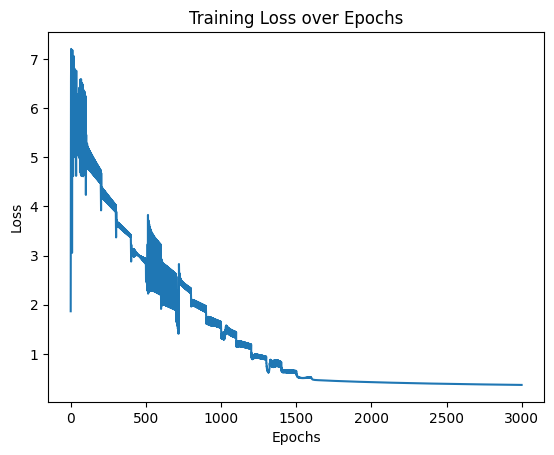

In [7]:
model = OneLayerNN(input_size=IMG_SIZE * IMG_SIZE, output_size=5)
errors = model.fit(X_train, Y_train, log_interval=100, epochs=3000, learning_rate=0.005)
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

Test Accuracy: 0.6222


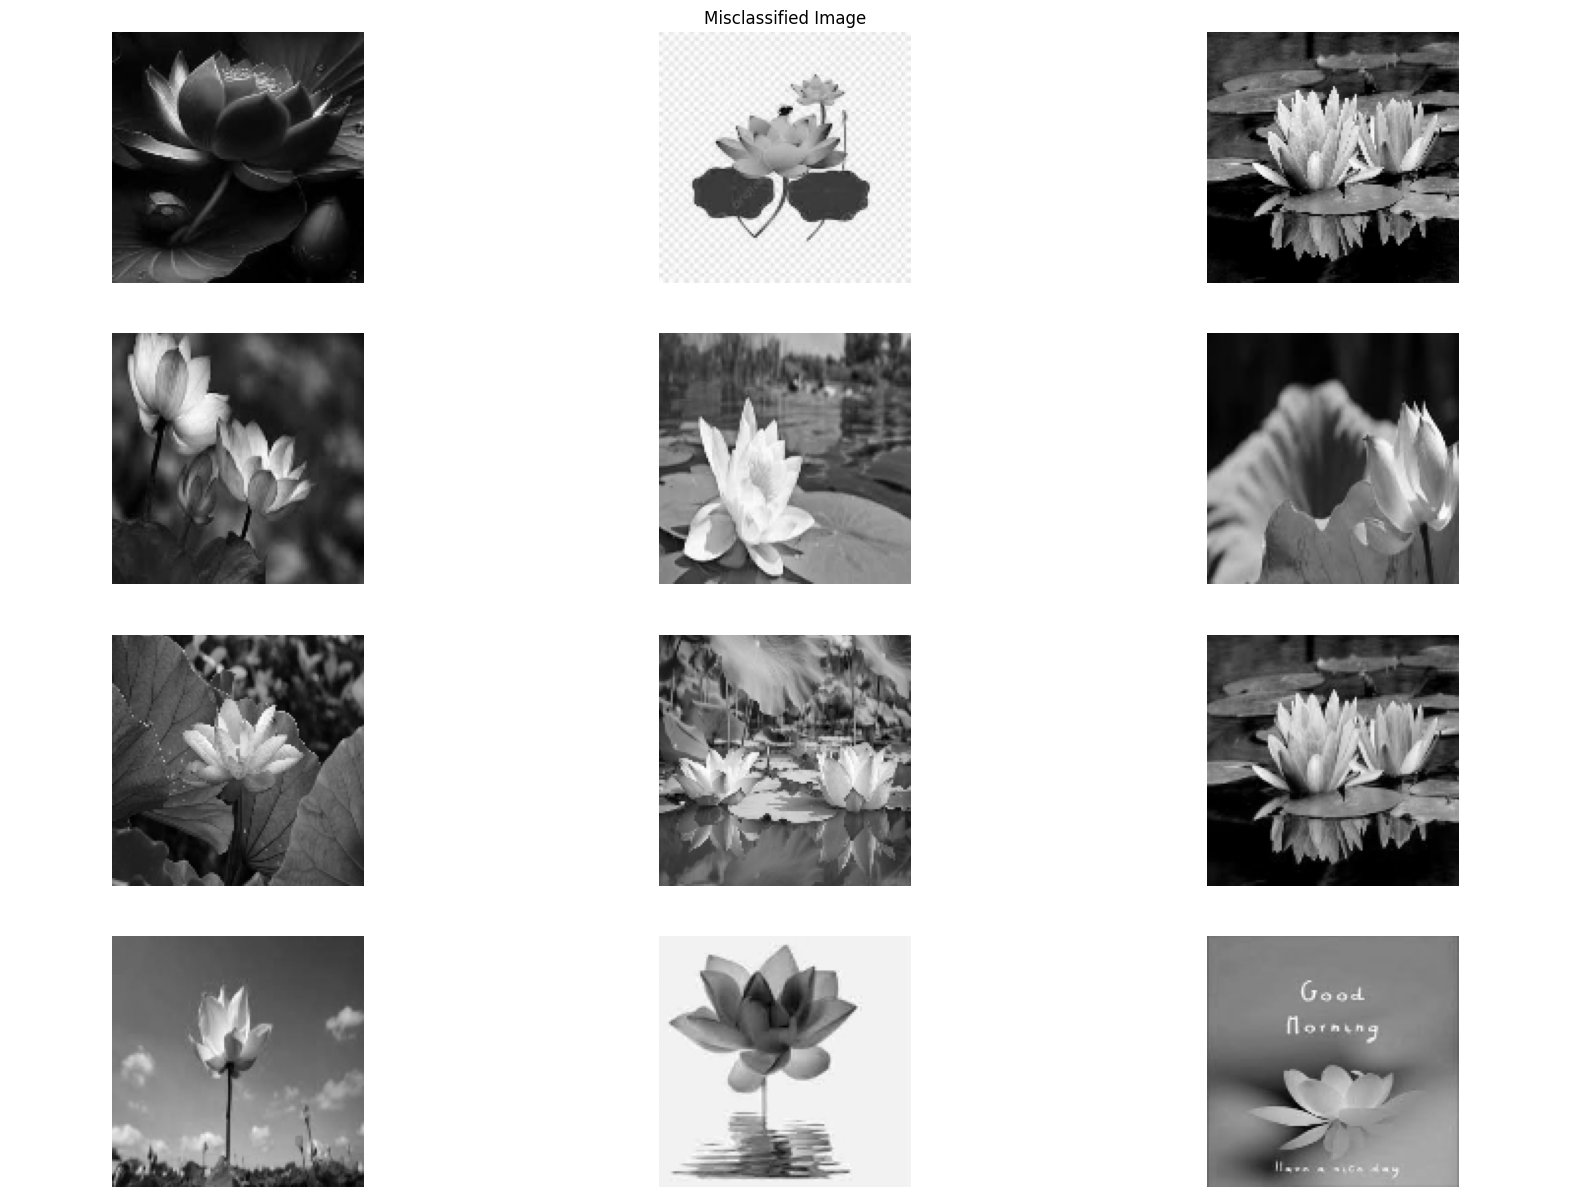

In [8]:
preds = model.predict(X_test)
accuracy = np.mean(preds == Y_test)
print(f"Test Accuracy: {accuracy:.4f}")
# first image to missclassify

r = 4
c = 3

missclassified =  X_test[(preds != Y_test)]

plt.figure(figsize=(20, 15))
plt.title("Misclassified Image")
plt.axis("off")
for i in range(r):
    for j in range(c):
        plt.subplot(r, c, i * c + j + 1)
        img = missclassified[i * c + j].reshape(IMG_SIZE, IMG_SIZE)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
plt.show()

Output()

Epoch 100/10000, Loss: 1.3817, Accuracy: 0.4474, Validation Accuracy: 0.3363, Weight norm: 13.5019

Epoch 200/10000, Loss: 1.2821, Accuracy: 0.5267, Validation Accuracy: 0.3739, Weight norm: 13.5162

Epoch 300/10000, Loss: 1.2097, Accuracy: 0.5871, Validation Accuracy: 0.4065, Weight norm: 13.5429

Epoch 400/10000, Loss: 1.1515, Accuracy: 0.6218, Validation Accuracy: 0.4332, Weight norm: 13.5851

...

Epoch 9600/10000, Loss: 0.5542, Accuracy: 0.8912, Validation Accuracy: 0.6142, Weight norm: 26.4938

Epoch 9700/10000, Loss: 0.5541, Accuracy: 0.8912, Validation Accuracy: 0.6142, Weight norm: 26.5394

Epoch 9800/10000, Loss: 0.5541, Accuracy: 0.8912, Validation Accuracy: 0.6152, Weight norm: 26.5830

Epoch 9900/10000, Loss: 0.5541, Accuracy: 0.8912, Validation Accuracy: 0.6152, Weight norm: 26.6244

Epoch 10000/10000, Loss: 0.5540, Accuracy: 0.8912, Validation Accuracy: 0.6152, Weight norm: 26.6640

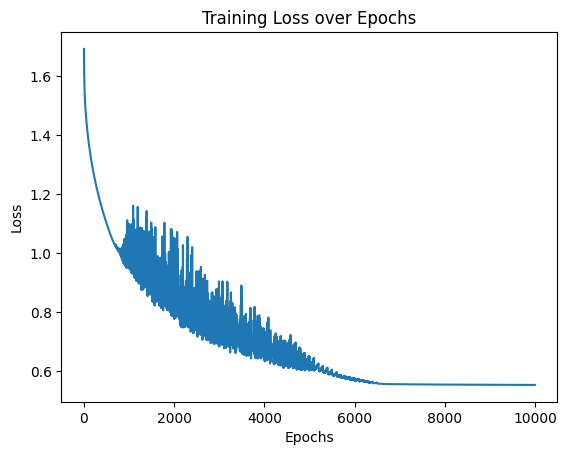

In [ ]:
class TwoLayerNN(AbstractClassifier):
    def __init__(self, input_size: int, hidden_layer_size: int, output_size: int):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_layer_size = hidden_layer_size

        self.weights1 = np.random.randn(input_size + 1, hidden_layer_size) * np.sqrt(1.0 / input_size)
        self.weights2 = np.random.randn(hidden_layer_size, output_size) * np.sqrt(1.0 / hidden_layer_size)
        self.cache = {}

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12) # log 0 problem
        return - (1 / m) * np.sum(y_true * np.log(y_pred))

    def relu(self, X):
        return np.maximum(0, X)
    
    def forward(self, X):
        z1 = np.dot(X, self.weights1)
        self.cache["X"] = X
        self.cache["z1"] = z1
        a1 = self.relu(z1)          
        self.cache["a1"] = a1 

        z2 = np.dot(a1, self.weights2)
        a2 = self.softmax(z2)
        self.cache["z2"] = z2
        self.cache["a2"] = a2
        return a2

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        pred = self.cache["a2"]

        # Gradient of cross-entropy with softmax is simply (a - y) / m
        dL_da2 = (pred - y) / m

        da2_dz2 = pred * (1 - pred)  # softmax derivative
        dz2_dw2 = self.cache["a1"]
        dz2_da1 = self.weights2
        da1_dz1 = (self.cache["a1"] > 0).astype(float)  # ReLU derivative
        dz1_dw1 = self.cache["X"]

        dL_dw2 = np.dot(dz2_dw2.T, dL_da2 * da2_dz2)
        dL_dw1 = np.dot(dz1_dw1.T, (np.dot(dL_da2 * da2_dz2, dz2_da1.T) * da1_dz1))


        self.weights1 -= learning_rate * dL_dw1
        self.weights2 -= learning_rate * dL_dw2
        self.cache = {}   # clear cache

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 1000,
        learning_rate: float = 0.1,
        log_interval: int = 100,
        shuffle: bool = True,
        random_seed: int = 42
    ):

        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X)

        X_with_bias = np.hstack((X_train_scaled, np.ones((X_train_scaled.shape[0], 1))))

        encoder = OneHotEncoder(sparse_output=False)
        y_encoded = encoder.fit_transform(y.reshape(-1, 1))

        if random_seed is not None:
            np.random.seed(random_seed)
        
        self.train_args = {
            "shuffle": shuffle,
            "log_interval": log_interval,
            "X": X_with_bias,
            "y": y_encoded,
            "learning_rate": learning_rate,
        }
        return self._train(epochs=epochs)

    def _train(self, *_, epochs: int):
        learning_rate = self.train_args["learning_rate"]
        X = self.train_args["X"]
        y = self.train_args["y"]
        shuffle = self.train_args["shuffle"]
        log_interval = self.train_args["log_interval"]
        
        errors = []
        for epoch in track(range(epochs), description="Training..."):
            if shuffle:
                indices = np.random.permutation(X.shape[0])
                X_batch = X[indices]
                y_batch = y[indices]
                y_batch = y[indices]
            else:
                X_batch = X
                y_batch = y

            preds = self.forward(X_batch)

            # Loss
            loss = self.cross_entropy_loss(y_batch, preds)
            errors.append(loss)

            epoch_learning_rate = learning_rate * (0.95 ** (epoch // 100)) 
            self.backward(X_batch, y_batch, epoch_learning_rate)

            # Logging
            if (epoch + 1) % log_interval == 0:
                predictions = np.argmax(preds, axis=1)
                actual = np.argmax(y_batch, axis=1)
                accuracy = np.mean(predictions == actual)

                val_preds = self.predict(X_test)
                val_accuracy = np.mean(val_preds == Y_test)

                weight_norm = np.linalg.norm(self.weights1) + np.linalg.norm(self.weights2)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, "
                      f"Accuracy: {accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Weight norm: {weight_norm:.4f}")

                if np.all(predictions == predictions[0]):
                    print("WARNING: All predictions are identical!")

        return errors

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.hstack((X_scaled, np.ones((X_scaled.shape[0], 1))))
        a = self.forward(X_with_bias)
        return np.argmax(a, axis=1)

model = TwoLayerNN(input_size=IMG_SIZE * IMG_SIZE, output_size=5, hidden_layer_size=128)
errors = model.fit(X_train, Y_train, log_interval=100, epochs=10000, learning_rate=0.01)
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

Output()

Epoch 100/1000, Loss: 0.4319, Accuracy: 0.9000, Validation Accuracy: 0.6271, Weight norm: 16.8290

Epoch 200/1000, Loss: 0.4317, Accuracy: 0.8925, Validation Accuracy: 0.6291, Weight norm: 16.9533

Epoch 300/1000, Loss: 0.4168, Accuracy: 0.8980, Validation Accuracy: 0.6291, Weight norm: 17.1049

Epoch 400/1000, Loss: 0.4618, Accuracy: 0.8787, Validation Accuracy: 0.5984, Weight norm: 17.2528

...

Epoch 600/1000, Loss: 0.3925, Accuracy: 0.9044, Validation Accuracy: 0.6419, Weight norm: 17.5668

Epoch 700/1000, Loss: 0.3989, Accuracy: 0.9069, Validation Accuracy: 0.6508, Weight norm: 17.7166

Epoch 800/1000, Loss: 0.2860, Accuracy: 0.9494, Validation Accuracy: 0.6756, Weight norm: 17.8737

Epoch 900/1000, Loss: 0.3038, Accuracy: 0.9386, Validation Accuracy: 0.6528, Weight norm: 18.0116

Epoch 1000/1000, Loss: 0.4042, Accuracy: 0.8947, Validation Accuracy: 0.6449, Weight norm: 18.1715

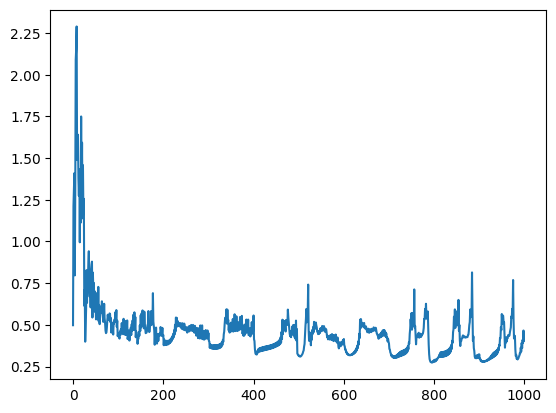

In [13]:
errors2 = model._train(epochs = 1000)
plt.plot(errors2)

Output()

Epoch 100/10000, Loss: 1.1404, Accuracy: 0.5836, Val Loss: 1.4172, Val Accuracy: 0.4045, Weight norm: 13.5217

Epoch 200/10000, Loss: 1.0219, Accuracy: 0.6465, Val Loss: 1.3545, Val Accuracy: 0.4599, Weight norm: 13.6059

Epoch 300/10000, Loss: 0.8281, Accuracy: 0.7363, Val Loss: 1.3236, Val Accuracy: 0.5025, Weight norm: 13.7120

Epoch 400/10000, Loss: 0.6500, Accuracy: 0.8331, Val Loss: 1.1931, Val Accuracy: 0.5776, Weight norm: 13.8251

...

Epoch 4300/10000, Loss: 0.0437, Accuracy: 0.9983, Val Loss: 0.9339, Val Accuracy: 0.7191, Weight norm: 15.0456

Epoch 4400/10000, Loss: 0.0449, Accuracy: 0.9983, Val Loss: 0.9350, Val Accuracy: 0.7201, Weight norm: 15.0495

Epoch 4500/10000, Loss: 0.0430, Accuracy: 0.9978, Val Loss: 0.9358, Val Accuracy: 0.7191, Weight norm: 15.0533

Epoch 4600/10000, Loss: 0.0425, Accuracy: 0.9975, Val Loss: 0.9363, Val Accuracy: 0.7201, Weight norm: 15.0568

Epoch 4700/10000, Loss: 0.0443, Accuracy: 0.9975, Val Loss: 0.9370, Val Accuracy: 0.7201, Weight norm: 15.0601

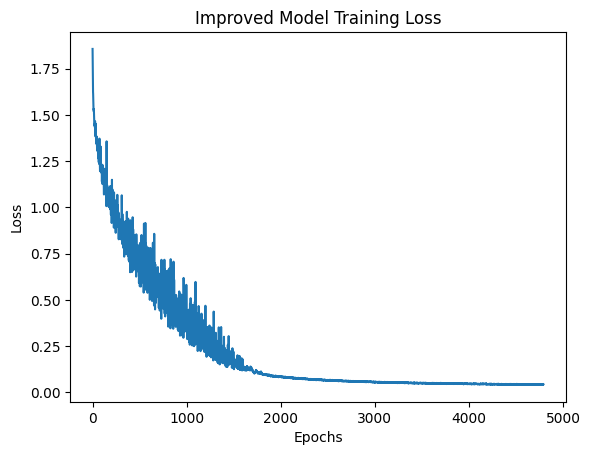

In [26]:
class TwoLayerNNImproved(AbstractClassifier):
    def __init__(
        self,
        input_size: int,
        hidden_layer_size: int,
        output_size: int,
        dropout_rate: float = 0.0,
        l2_lambda: float = 0.0,
        use_batchnorm: bool = False,
        bn_momentum: float = 0.9,
        bn_eps: float = 1e-5,
    ):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_layer_size = hidden_layer_size
        self.dropout_rate = dropout_rate
        self.l2_lambda = l2_lambda
        self.use_batchnorm = use_batchnorm
        self.bn_momentum = bn_momentum
        self.bn_eps = bn_eps

        self.weights1 = np.random.randn(input_size + 1, hidden_layer_size) * np.sqrt(1.0 / input_size)
        self.weights2 = np.random.randn(hidden_layer_size, output_size) * np.sqrt(1.0 / hidden_layer_size)
        self.cache = {}

        if self.use_batchnorm:
            self.gamma = np.ones(hidden_layer_size)
            self.beta = np.zeros(hidden_layer_size)
            self.running_mean = np.zeros(hidden_layer_size)
            self.running_var = np.ones(hidden_layer_size)

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        base_loss = - (1 / m) * np.sum(y_true * np.log(y_pred))
        if self.l2_lambda > 0:
            l2_term = (self.l2_lambda / (2 * m)) * (np.sum(self.weights1 ** 2) + np.sum(self.weights2 ** 2))
            return base_loss + l2_term
        return base_loss

    def relu(self, X):
        return np.maximum(0, X)

    def _batchnorm_forward(self, z, training: bool):
        if training:
            mean = np.mean(z, axis=0)
            var = np.var(z, axis=0)
            z_hat = (z - mean) / np.sqrt(var + self.bn_eps)
            out = self.gamma * z_hat + self.beta
            self.running_mean = self.bn_momentum * self.running_mean + (1 - self.bn_momentum) * mean
            self.running_var = self.bn_momentum * self.running_var + (1 - self.bn_momentum) * var
            self.cache["bn_cache"] = (z, z_hat, mean, var)
            return out
        z_hat = (z - self.running_mean) / np.sqrt(self.running_var + self.bn_eps)
        return self.gamma * z_hat + self.beta

    def _batchnorm_backward(self, dout):
        z, z_hat, mean, var = self.cache["bn_cache"]
        m = z.shape[0]
        dbeta = np.sum(dout, axis=0)
        dgamma = np.sum(dout * z_hat, axis=0)
        dz_hat = dout * self.gamma
        dvar = np.sum(dz_hat * (z - mean) * -0.5 * (var + self.bn_eps) ** (-1.5), axis=0)
        dmean = np.sum(dz_hat * -1 / np.sqrt(var + self.bn_eps), axis=0) + dvar * np.sum(-2 * (z - mean), axis=0) / m
        dz = dz_hat / np.sqrt(var + self.bn_eps) + dvar * 2 * (z - mean) / m + dmean / m
        return dz, dgamma, dbeta

    def forward(self, X, training: bool = True):
        z1 = np.dot(X, self.weights1)
        if self.use_batchnorm:
            z1 = self._batchnorm_forward(z1, training=training)
        self.cache["X"] = X
        self.cache["z1"] = z1
        a1 = self.relu(z1)
        if training and self.dropout_rate > 0:
            mask = (np.random.rand(*a1.shape) >= self.dropout_rate) / (1 - self.dropout_rate)
            a1 = a1 * mask
            self.cache["dropout_mask"] = mask
        self.cache["a1"] = a1

        z2 = np.dot(a1, self.weights2)
        a2 = self.softmax(z2)
        self.cache["z2"] = z2
        self.cache["a2"] = a2
        return a2

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        pred = self.cache["a2"]

        dZ2 = (pred - y) / m
        dW2 = np.dot(self.cache["a1"].T, dZ2)
        dA1 = np.dot(dZ2, self.weights2.T)

        if self.dropout_rate > 0 and "dropout_mask" in self.cache:
            dA1 = dA1 * self.cache["dropout_mask"]

        dZ1 = dA1 * (self.cache["z1"] > 0).astype(float)

        if self.use_batchnorm:
            dZ1, dgamma, dbeta = self._batchnorm_backward(dZ1)
            self.gamma -= learning_rate * dgamma
            self.beta -= learning_rate * dbeta

        dW1 = np.dot(X.T, dZ1)

        if self.l2_lambda > 0:
            dW2 += (self.l2_lambda / m) * self.weights2
            dW1 += (self.l2_lambda / m) * self.weights1

        self.weights1 -= learning_rate * dW1
        self.weights2 -= learning_rate * dW2
        self.cache = {}

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 1000,
        learning_rate: float = 0.1,
        log_interval: int = 100,
        shuffle: bool = True,
        random_seed: int = 42,
        early_stopping: bool = True,
        patience: int = 10,
        min_delta: float = 0.0,
        X_val: np.ndarray = None,
        y_val: np.ndarray = None,
    ):
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X)
        X_with_bias = np.hstack((X_train_scaled, np.ones((X_train_scaled.shape[0], 1))))

        self.encoder = OneHotEncoder(sparse_output=False)
        y_encoded = self.encoder.fit_transform(y.reshape(-1, 1))

        if random_seed is not None:
            np.random.seed(random_seed)

        self.train_args = {
            "shuffle": shuffle,
            "log_interval": log_interval,
            "X": X_with_bias,
            "y": y_encoded,
            "learning_rate": learning_rate,
            "early_stopping": early_stopping,
            "patience": patience,
            "min_delta": min_delta,
            "X_val": X_val,
            "y_val": y_val,
        }
        return self._train(epochs=epochs)

    def _train(self, *_, epochs: int):
        learning_rate = self.train_args["learning_rate"]
        X = self.train_args["X"]
        y = self.train_args["y"]
        shuffle = self.train_args["shuffle"]
        log_interval = self.train_args["log_interval"]
        early_stopping = self.train_args["early_stopping"]
        patience = self.train_args["patience"]
        min_delta = self.train_args["min_delta"]
        X_val = self.train_args["X_val"]
        y_val = self.train_args["y_val"]

        errors = []
        best_loss = np.inf
        best_val_acc = 0.0
        bad_epochs = 0
        best_state = None

        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(self.train_args["X_val"])
            X_val = np.hstack((X_val_scaled, np.ones((X_val_scaled.shape[0], 1))))
            y_val = self.encoder.transform(self.train_args["y_val"].reshape(-1, 1))

        for epoch in track(range(epochs), description="Training..."):
            if shuffle:
                indices = np.random.permutation(X.shape[0])
                X_batch = X[indices]
                y_batch = y[indices]
            else:
                X_batch = X
                y_batch = y

            preds = self.forward(X_batch, training=True)
            loss = self.cross_entropy_loss(y_batch, preds)
            errors.append(loss)

            epoch_learning_rate = learning_rate * (0.95 ** (epoch // 100))
            self.backward(X_batch, y_batch, epoch_learning_rate)

            if X_val is not None and y_val is not None: 
                val_preds = self.forward(X_val, training=False)
                val_loss = self.cross_entropy_loss(y_val, val_preds)

            if loss + min_delta < best_loss:
                best_loss = loss
                if X_val is not None and y_val is not None:
                    best_val_acc = np.mean(np.argmax(val_preds, axis=1) == np.argmax(y_val, axis=1))
                bad_epochs = 0
                if self.use_batchnorm:
                    best_state = (
                        self.weights1.copy(),
                        self.weights2.copy(),
                        self.gamma.copy(),
                        self.beta.copy(),
                        self.running_mean.copy(),
                        self.running_var.copy(),
                    )
                else:
                    best_state = (self.weights1.copy(), self.weights2.copy())
            else:
                bad_epochs += 1
                if early_stopping and bad_epochs >= patience:
                    message = f"Early stopping at epoch {epoch+1}."
                    if X_val is not None and y_val is not None:
                        message += f" Best loss: {best_loss:.4f}, Best val acc: {best_val_acc:.4f}"
                    break

            if (epoch + 1) % log_interval == 0:
                message = f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}"

                predictions = np.argmax(preds, axis=1)
                actual = np.argmax(y_batch, axis=1)
                accuracy = np.mean(predictions == actual)
                message += f", Accuracy: {accuracy:.4f}"
                if X_val is not None and y_val is not None:
                    val_preds_labels = np.argmax(val_preds, axis=1)
                    val_actual = np.argmax(y_val, axis=1)
                    val_accuracy = np.mean(val_preds_labels == val_actual)
                    message += f", Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
                weight_norm = np.linalg.norm(self.weights1) + np.linalg.norm(self.weights2)
                message += f", Weight norm: {weight_norm:.4f}"
                print(message)
                if np.all(predictions == predictions[0]):
                    print("WARNING: All predictions are identical!")

        if early_stopping and best_state is not None:
            if self.use_batchnorm:
                (
                    self.weights1,
                    self.weights2,
                    self.gamma,
                    self.beta,
                    self.running_mean,
                    self.running_var,
                ) = best_state
            else:
                self.weights1, self.weights2 = best_state

        return errors

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.hstack((X_scaled, np.ones((X_scaled.shape[0], 1))))
        a = self.forward(X_with_bias, training=False)
        return np.argmax(a, axis=1)

improved_model = TwoLayerNNImproved(
    input_size=IMG_SIZE * IMG_SIZE,
    output_size=5,
    hidden_layer_size=128,
    dropout_rate=0.3,
    l2_lambda=1e-4,
    use_batchnorm=True,
 )
improved_errors = improved_model.fit(
    X_train,
    Y_train,
    log_interval=100,
    epochs=10000,
    learning_rate=0.01,
    early_stopping=True,
    patience=200,
    min_delta=1e-4,
    X_val=X_test,
    y_val=Y_test
 )
plt.plot(improved_errors)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Improved Model Training Loss")
plt.show()

(1011, 9216) (1011, 25088) AAAAAAAAAAAAAAAa


Output()

Epoch 100/2000, Loss: 0.5266, Accuracy: 0.8653, Val Loss: 0.7198, Val Accuracy: 0.7873, Weight norm: 13.6667

Epoch 200/2000, Loss: 0.3387, Accuracy: 0.9349, Val Loss: 0.5895, Val Accuracy: 0.8388, Weight norm: 13.8092

Epoch 300/2000, Loss: 0.2363, Accuracy: 0.9698, Val Loss: 0.5213, Val Accuracy: 0.8595, Weight norm: 13.9304

Epoch 400/2000, Loss: 0.1857, Accuracy: 0.9813, Val Loss: 0.4796, Val Accuracy: 0.8694, Weight norm: 14.0299

Epoch 500/2000, Loss: 0.1439, Accuracy: 0.9878, Val Loss: 0.4525, Val Accuracy: 0.8744, Weight norm: 14.1120

Epoch 600/2000, Loss: 0.1194, Accuracy: 0.9903, Val Loss: 0.4336, Val Accuracy: 0.8783, Weight norm: 14.1803

Epoch 700/2000, Loss: 0.1001, Accuracy: 0.9943, Val Loss: 0.4203, Val Accuracy: 0.8823, Weight norm: 14.2379

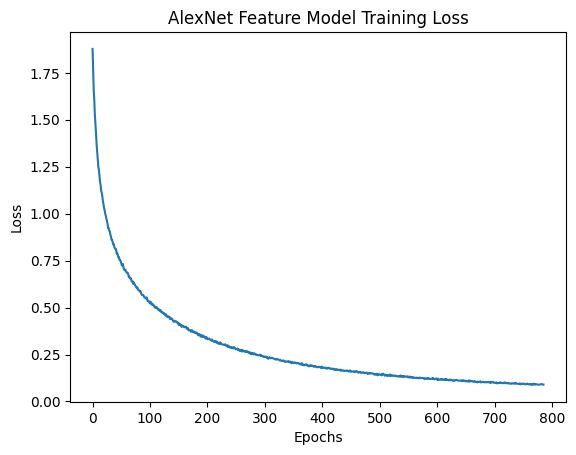

Output()

Epoch 100/2000, Loss: 0.2971, Accuracy: 0.9703, Val Loss: 0.5720, Val Accuracy: 0.8506, Weight norm: 13.6779

Epoch 200/2000, Loss: 0.1561, Accuracy: 0.9935, Val Loss: 0.4600, Val Accuracy: 0.8734, Weight norm: 13.8173

Epoch 300/2000, Loss: 0.1022, Accuracy: 0.9975, Val Loss: 0.4115, Val Accuracy: 0.8803, Weight norm: 13.9155

Epoch 400/2000, Loss: 0.0744, Accuracy: 0.9975, Val Loss: 0.3856, Val Accuracy: 0.8813, Weight norm: 13.9884

Epoch 500/2000, Loss: 0.0566, Accuracy: 0.9983, Val Loss: 0.3701, Val Accuracy: 0.8823, Weight norm: 14.0449

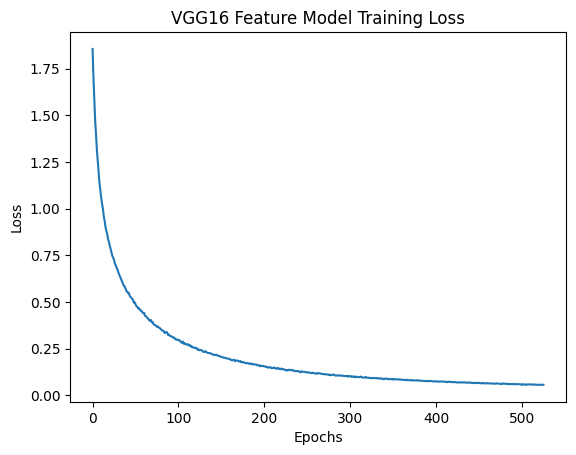

In [28]:
import torch
import torch.nn.functional as F
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _to_3ch_224(x_flat: np.ndarray) -> torch.Tensor:
    x = x_flat.reshape(-1, IMG_SIZE, IMG_SIZE)
    x = torch.from_numpy(x).float() / 255.0
    x = x.unsqueeze(1).repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
    return x

def _extract_features(model, X_np: np.ndarray, batch_size: int = 32) -> np.ndarray:
    feats = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            batch = _to_3ch_224(X_np[i:i + batch_size]).to(device)
            out = model(batch)
            feats.append(out.cpu().numpy())
    return np.vstack(feats)

alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
alexnet.classifier = torch.nn.Identity()
for p in alexnet.parameters():
    p.requires_grad = False
alexnet = alexnet.to(device)
alexnet_train_feats = _extract_features(alexnet, X_train)
alexnet_test_feats = _extract_features(alexnet, X_test)
print(alexnet_test_feats.shape, vgg16_test_feats.shape, "AAAAAAAAAAAAAAAa")
alexnet_head = TwoLayerNNImproved(
    input_size=alexnet_train_feats.shape[1],
    output_size=5,
    hidden_layer_size=128,
    dropout_rate=0.3,
    l2_lambda=1e-4,
    use_batchnorm=True,
 )
alexnet_errors = alexnet_head.fit(
    alexnet_train_feats,
    Y_train,
    log_interval=100,
    epochs=2000,
    learning_rate=0.01,
    early_stopping=True,
    patience=20,
    min_delta=1e-4,
    X_val=alexnet_test_feats,
    y_val=Y_test
 )
plt.plot(alexnet_errors)
plt.title("AlexNet Feature Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
vgg16.classifier = torch.nn.Identity()
for p in vgg16.parameters():
    p.requires_grad = False
vgg16 = vgg16.to(device)


vgg16_train_feats = _extract_features(vgg16, X_train)
vgg16_test_feats = _extract_features(vgg16, X_test)


vgg16_head = TwoLayerNNImproved(
    input_size=vgg16_train_feats.shape[1],
    output_size=5,
    hidden_layer_size=128,
    dropout_rate=0.3,
    l2_lambda=1e-4,
    use_batchnorm=True,
 )
vgg16_errors = vgg16_head.fit(
    vgg16_train_feats,
    Y_train,
    log_interval=100,
    epochs=2000,
    learning_rate=0.01,
    early_stopping=True,
    patience=20,
    min_delta=1e-4,
    X_val = vgg16_test_feats,
    y_val = Y_test
 )
plt.plot(vgg16_errors)
plt.title("VGG16 Feature Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()